# 02 - Wafer Map Story

This notebook turns the generated tables into wafer maps. The goal is to answer three spatial questions:

1. Where do we have downstream test coverage?
2. Where do tested dies pass or fail the downstream spec?
3. Do failures look spatially structured, or are they just random dots?

The maps use real die squares on a circular lattice. Grey cells are not missing from the inline table; they simply have no downstream test row.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Patch, Rectangle
from matplotlib.colors import Normalize

from src.utils import load_sources, validate_schemas


In [2]:
df_inline, df_downstream = load_sources(input_dir=str(DATA_DIR), prefix='synthetic')
validate_schemas(df_inline, df_downstream)

pitch_x = float(np.diff(np.sort(df_inline['x_mm'].unique())).min())
pitch_y = float(np.diff(np.sort(df_inline['y_mm'].unique())).min())
die_size = min(pitch_x, pitch_y) * 0.92
wafer_radius = float(df_inline['r_mm'].max()) + 0.5 * max(pitch_x, pitch_y)

print(f'Inline dies: {len(df_inline)}')
print(f'Downstream tested dies: {len(df_downstream)}')
print(f'Not tested dies: {len(df_inline) - len(df_downstream)}')
print(f'Die pitch: {pitch_x:.2f} mm x {pitch_y:.2f} mm')

Loaded inline metrology: e:\Data_Science_Proj\data\synthetic_inline_metrology.csv
Loaded downstream wafer test: e:\Data_Science_Proj\data\synthetic_downstream_wafer_test.csv
Inline dies: 8000
Downstream tested dies: 3743
Not tested dies: 4257
Die pitch: 6.09 mm x 6.09 mm


In [3]:
df_status = df_inline.merge(
    df_downstream[['wafer_id', 'die_id', 'lambda_res_nm', 'q_loaded', 'test_pass']],
    on=['wafer_id', 'die_id'],
    how='left',
)

def classify_status(test_pass):
    if pd.isna(test_pass):
        return 'Not tested downstream'
    if int(test_pass) == 1:
        return 'Pass downstream spec'
    return 'Fail downstream spec'

status_order = [
    'Pass downstream spec',
    'Fail downstream spec',
    'Not tested downstream',
]
df_status['tested_downstream'] = df_status['test_pass'].notna()
df_status['downstream_status'] = df_status['test_pass'].apply(classify_status)
df_status['downstream_status'] = pd.Categorical(
    df_status['downstream_status'],
    categories=status_order,
    ordered=True,
)

status_counts = df_status['downstream_status'].value_counts().reindex(status_order)
display(status_counts.to_frame('die_count'))

,die_count
downstream_status,
Pass downstream spec,2261
Fail downstream spec,1482
Not tested downstream,4257


## Helper functions

The plotting helpers below draw each die as a small square. The wafer outline is circular, so empty corners are expected: those grid locations are outside the usable wafer footprint.

In [4]:
status_palette = {
    'Pass downstream spec': '#2C7FB8',
    'Fail downstream spec': '#D95F0E',
    'Not tested downstream': '#D9D9D9',
}

def set_wafer_axes(ax):
    ax.add_patch(Circle((0, 0), wafer_radius, fill=False, edgecolor='black', linewidth=1.0))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-wafer_radius - die_size, wafer_radius + die_size)
    ax.set_ylim(-wafer_radius - die_size, wafer_radius + die_size)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')


def rectangles_for(df):
    return [
        Rectangle((row.x_mm - die_size / 2, row.y_mm - die_size / 2), die_size, die_size)
        for row in df.itertuples(index=False)
    ]


def draw_status_map(ax, wafer_df):
    rects = rectangles_for(wafer_df)
    colors = [status_palette[str(status)] for status in wafer_df['downstream_status']]
    collection = PatchCollection(rects, facecolor=colors, edgecolor='white', linewidth=0.2)
    ax.add_collection(collection)
    set_wafer_axes(ax)


def draw_lambda_map(ax, wafer_df, lambda_min, lambda_max):
    not_tested = wafer_df[~wafer_df['tested_downstream']]
    tested = wafer_df[wafer_df['tested_downstream']]

    if len(not_tested):
        grey = PatchCollection(
            rectangles_for(not_tested),
            facecolor='#D9D9D9',
            edgecolor='white',
            linewidth=0.2,
        )
        ax.add_collection(grey)

    collection = None
    if len(tested):
        collection = PatchCollection(
            rectangles_for(tested),
            cmap='turbo',
            norm=Normalize(vmin=lambda_min, vmax=lambda_max),
            edgecolor='white',
            linewidth=0.2,
        )
        collection.set_array(tested['lambda_res_nm'].to_numpy())
        ax.add_collection(collection)

    set_wafer_axes(ax)
    return collection

## Pick a wafer with a visible story

Instead of choosing a wafer by hand, we select the wafer with many downstream failures and high resonance spread. This usually highlights the synthetic local effects most clearly.

In [5]:
wafer_summary = (
    df_status.groupby('wafer_id')
    .agg(
        tested_count=('tested_downstream', 'sum'),
        fail_count=('test_pass', lambda s: int((s == 0).sum())),
        not_tested_count=('tested_downstream', lambda s: int((~s).sum())),
        lambda_std=('lambda_res_nm', 'std'),
    )
    .fillna({'lambda_std': 0.0})
)
wafer_summary['fail_rate_among_tested'] = wafer_summary['fail_count'] / wafer_summary['tested_count']
selected_wafer = wafer_summary.sort_values(
    ['fail_count', 'lambda_std'],
    ascending=False,
).index[0]

print(f'Selected wafer: {selected_wafer}')
display(wafer_summary.sort_values(['fail_count', 'lambda_std'], ascending=False).head(8))

Selected wafer: W005


,tested_count,fail_count,not_tested_count,lambda_std,fail_rate_among_tested
wafer_id,,,,,
W005,189,186,211,0.607966,0.984127
W013,199,159,201,0.653663,0.798995
W001,181,142,219,0.647806,0.784530
W008,136,110,264,0.696908,0.808824
W012,184,109,216,0.647416,0.592391
W020,171,108,229,0.651577,0.631579
W017,187,107,213,0.660932,0.572193
W007,187,98,213,0.756997,0.524064


## Resonance map for one wafer

This map colors tested dies by `lambda_res_nm`. Untested dies are grey. The plot is useful because it connects the numerical target back to physical wafer position.

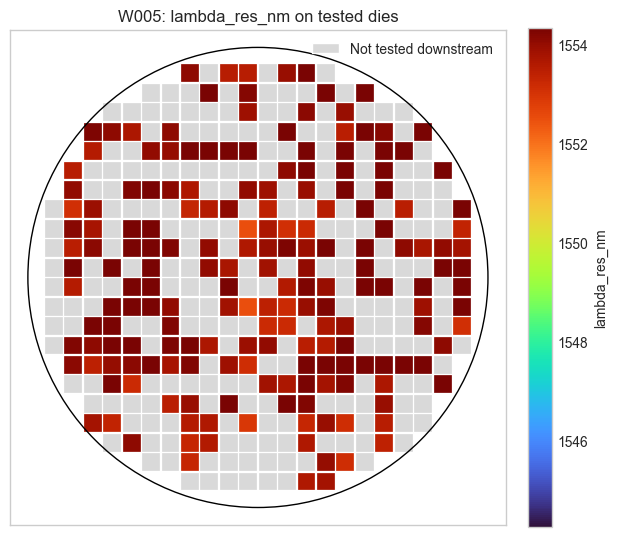

In [6]:
wafer_df = df_status[df_status['wafer_id'] == selected_wafer].copy()
lambda_min = float(df_downstream['lambda_res_nm'].quantile(0.02))
lambda_max = float(df_downstream['lambda_res_nm'].quantile(0.98))

fig, ax = plt.subplots(figsize=(7, 7))
collection = draw_lambda_map(ax, wafer_df, lambda_min=lambda_min, lambda_max=lambda_max)
ax.set_title(f'{selected_wafer}: lambda_res_nm on tested dies')
if collection is not None:
    cbar = fig.colorbar(collection, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('lambda_res_nm')
legend_handles = [Patch(facecolor='#D9D9D9', edgecolor='white', label='Not tested downstream')]
ax.legend(handles=legend_handles, loc='upper right')
plt.show()

## All wafers: pass, fail, and not tested

This view is the main spatial EDA product. A good synthetic process should not look like perfectly random confetti. Because the generator includes edge and semi-ring effects, failures and missing downstream coverage can show spatial structure.

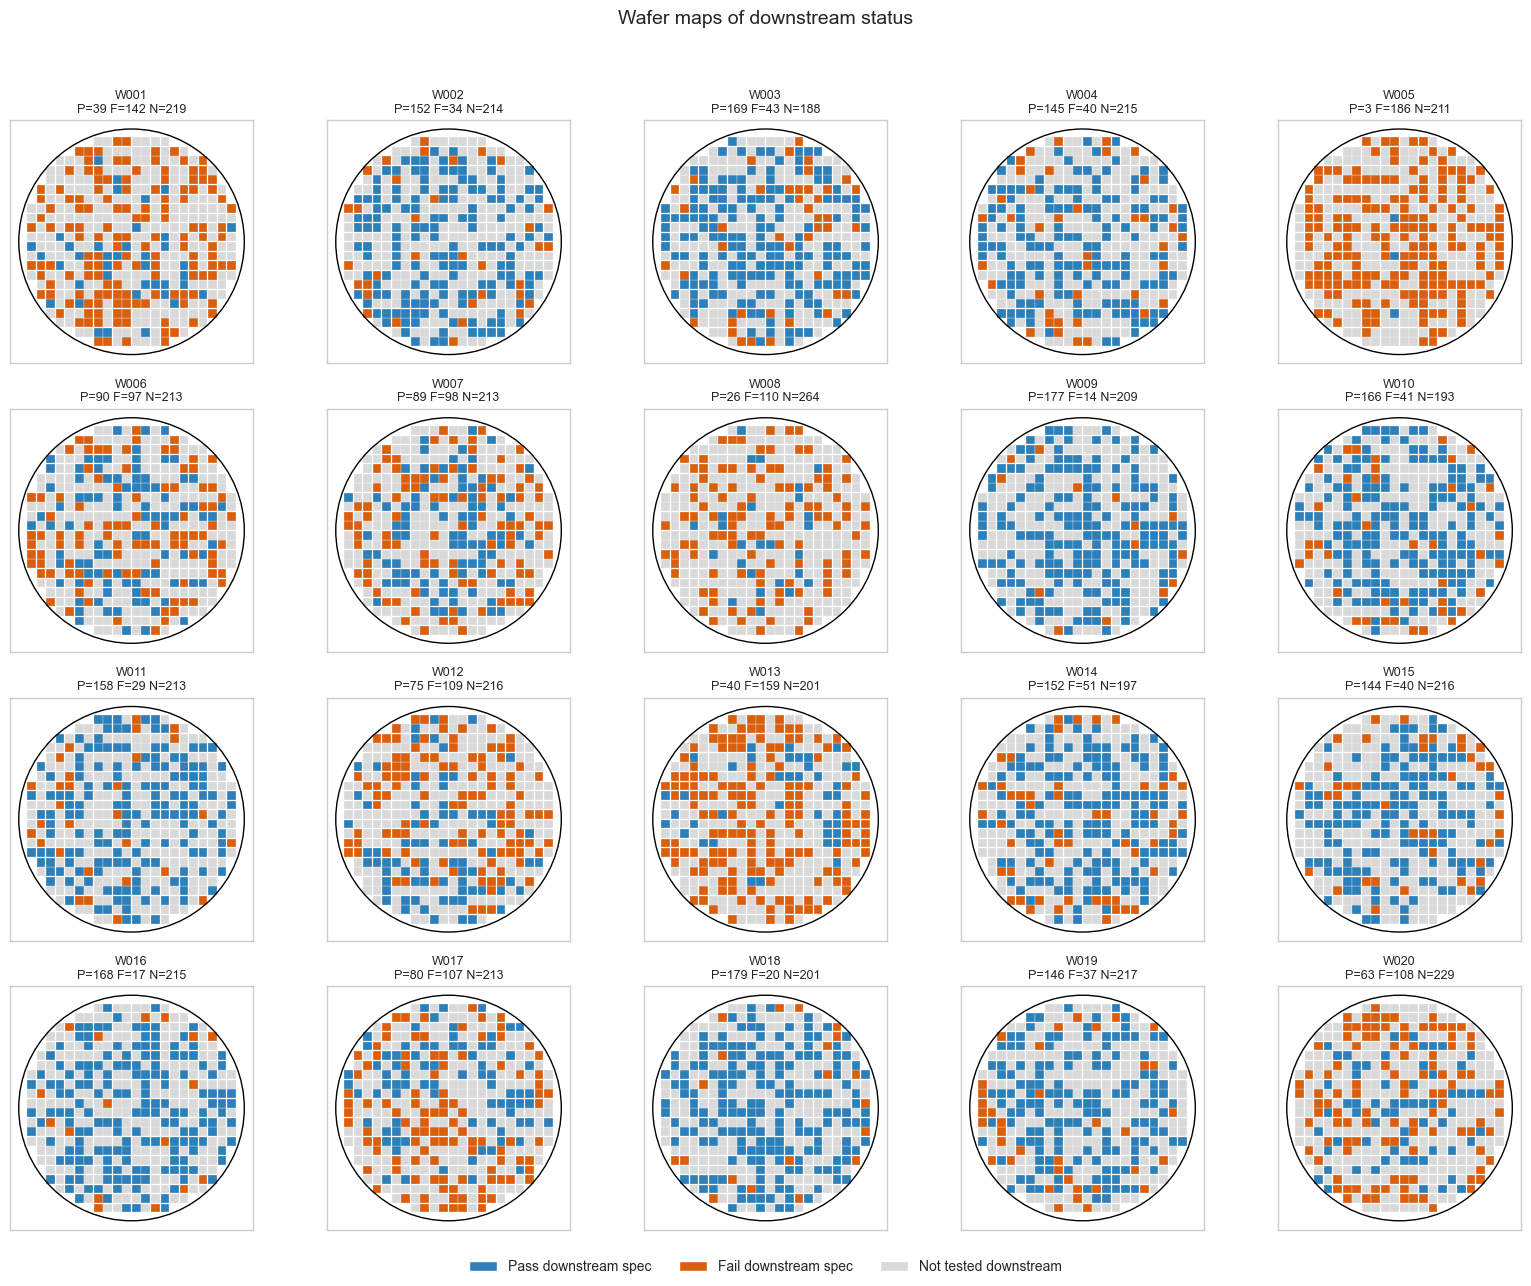

In [7]:
wafer_ids = sorted(df_status['wafer_id'].unique())
n_cols = 5
n_rows = int(np.ceil(len(wafer_ids) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = np.asarray(axes).ravel()

for ax, wafer_id in zip(axes, wafer_ids):
    wafer_df = df_status[df_status['wafer_id'] == wafer_id]
    draw_status_map(ax, wafer_df)
    counts = wafer_df['downstream_status'].value_counts()
    ax.set_title(
        f"{wafer_id}\n"
        f"P={int(counts.get('Pass downstream spec', 0))} "
        f"F={int(counts.get('Fail downstream spec', 0))} "
        f"N={int(counts.get('Not tested downstream', 0))}",
        fontsize=9,
    )

for ax in axes[len(wafer_ids):]:
    ax.set_visible(False)

legend_handles = [
    Patch(facecolor=color, edgecolor='white', label=label)
    for label, color in status_palette.items()
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Wafer maps of downstream status', y=0.995, fontsize=14)
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()

## Radial failure summary

The maps are visual evidence. This table and plot are a small numerical check: do tested dies fail more often near the edge than near the center?

,tested_count,fail_count,mean_lambda,mean_q,fail_rate
radius_bin,,,,,
"(4.303, 30.129]",757,244,1548.790920,164270.959350,0.322325
"(30.129, 42.391]",757,249,1549.542631,161445.637056,0.328930
"(42.391, 51.829]",757,263,1549.442345,159892.771859,0.347424
"(51.829, 60.411]",738,331,1548.984798,152957.516082,0.448509
"(60.411, 69.0]",734,395,1549.061671,148490.924033,0.538147


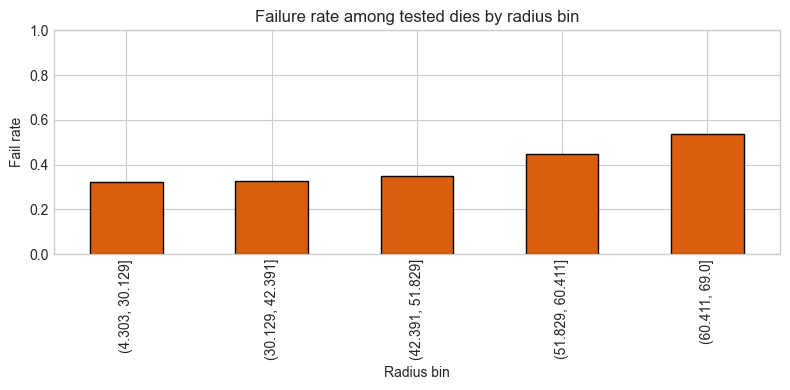

In [8]:
tested = df_status[df_status['tested_downstream']].copy()
tested['radius_bin'] = pd.qcut(tested['r_mm'], q=5)
radial_summary = (
    tested.groupby('radius_bin', observed=True)
    .agg(
        tested_count=('die_id', 'size'),
        fail_count=('test_pass', lambda s: int((s == 0).sum())),
        mean_lambda=('lambda_res_nm', 'mean'),
        mean_q=('q_loaded', 'mean'),
    )
)
radial_summary['fail_rate'] = radial_summary['fail_count'] / radial_summary['tested_count']
display(radial_summary)

fig, ax = plt.subplots(figsize=(8, 4))
radial_summary['fail_rate'].plot(kind='bar', ax=ax, color='#D95F0E', edgecolor='black')
ax.set_title('Failure rate among tested dies by radius bin')
ax.set_ylabel('Fail rate')
ax.set_xlabel('Radius bin')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## What this plot can support

This wafer-map notebook does not prove that the model is correct in a real fab. It supports a narrower claim: the synthetic data contains structured process variation that can be inspected spatially. Pass, fail, and not-tested states are visible at die level, and the failure pattern is not hidden inside a table.